In [2]:
import numpy as np
import pandas as pd

G = 1.0

def accel(r, m):
    """
    r: (3,3) positions
    m: (3,) masses
    return: (3,3) accelerations
    """
    a = np.zeros_like(r)
    for i in range(3):
        for j in range(3):
            if i != j:
                diff = r[j] - r[i]
                dist = np.linalg.norm(diff)
                a[i] += G * m[j] * diff / dist**3
    return a


def rk4_step(r, v, m, dt):
    k1r = v
    k1v = accel(r, m)

    k2r = v + 0.5 * dt * k1v
    k2v = accel(r + 0.5 * dt * k1r, m)

    k3r = v + 0.5 * dt * k2v
    k3v = accel(r + 0.5 * dt * k2r, m)

    k4r = v + dt * k3v
    k4v = accel(r + dt * k3r, m)

    r += dt / 6 * (k1r + 2*k2r + 2*k3r + k4r)
    v += dt / 6 * (k1v + 2*k2v + 2*k3v + k4v)
    return r, v


In [3]:
# ===== 参数 =====
dt = 0.01
steps = 5000

m = np.array([1.0, 1.0, 1.0])

# 初始位置 / 速度
r = np.array([
    [-0.5, 0.0, 0.0],
    [ 0.5, 0.0, 0.0],
    [ 0.0, 2.5, 0.0],
])

v = np.array([
    [ 0.0,  0.7, 0.0],
    [ 0.0, -0.7, 0.0],
    [ 0.0, -0.15, 0.0],
])

data = []

t = 0.0
for _ in range(steps):
    data.append([t, *r[0], *r[1], *r[2]])
    r, v = rk4_step(r, v, m, dt)
    t += dt


In [4]:
df = pd.DataFrame(
    data,
    columns=["t",
             "x1","y1","z1",
             "x2","y2","z2",
             "x3","y3","z3"]
)

df.to_csv("orbit.csv", index=False)


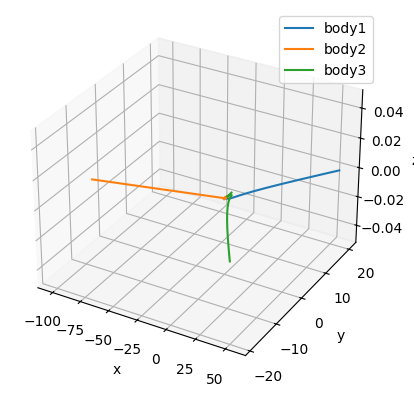

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("orbit.csv")

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

ax.plot(df.x1, df.y1, df.z1, label="body1")
ax.plot(df.x2, df.y2, df.z2, label="body2")
ax.plot(df.x3, df.y3, df.z3, label="body3")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()

plt.show()
